# Импорты библиотек

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import gradio as gr
import plotly.express as px

c:\Users\Dasha\Desktop\ML_hakaton\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Чтение данных

In [2]:
df = pd.read_excel('./incidents_2000.xlsx')
df.head()

,Тип предприятия,Код предприятия,Количество хостов,Код реализованной угрозы,Успех,Регион размещения предприятия,Дата инцидента,Региональное время
0,НКО,1825,251,190,1,Республика Марий,02.04.2024,02.04.2024 07:47
1,химия,8936,378,152,1,Республика Адыгея,03.03.2023,03.03.2023 05:13
2,отели,8280,1432,7,0,Севастополь,09.05.2025,09.05.2025 10:28
3,фармацевтика,4558,1857,223,0,Смоленская область,15.05.2025,15.05.2025 13:17
4,энергетика,3528,1763,87,0,Архангельская область,17.02.2025,17.02.2025 06:22


# Чистка и подготовка данных

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Тип предприятия                2000 non-null   str  
 1   Код предприятия                2000 non-null   int64
 2   Количество хостов              2000 non-null   int64
 3   Код реализованной угрозы       2000 non-null   int64
 4   Успех                          2000 non-null   int64
 5   Регион размещения предприятия  2000 non-null   str  
 6   Дата инцидента                 2000 non-null   str  
 7   Региональное время             2000 non-null   str  
dtypes: int64(4), str(4)
memory usage: 125.1 KB


In [4]:
df['Дата инцидента'] = pd.to_datetime(df['Дата инцидента'], format="%d.%m.%Y")
df['Региональное время'] = pd.to_datetime(df['Региональное время'], format="%d.%m.%Y %H:%M")

In [5]:
df[['Количество хостов', 'Регион размещения предприятия', 'Тип предприятия']] = df\
    .groupby('Код предприятия')[['Количество хостов', 'Регион размещения предприятия', 'Тип предприятия']]\
    .transform('first')

In [6]:
df.describe()

,Код предприятия,Количество хостов,Код реализованной угрозы,Успех,Дата инцидента,Региональное время
count,2000.000000,2000.000000,2000.000000,2000.000000,2000,2000
mean,5013.509500,1083.215000,114.440000,0.502500,2024-07-04 14:53:31.200000,2024-07-05 07:33:00.720000
min,6.000000,200.000000,1.000000,0.000000,2023-01-01 00:00:00,2023-01-01 05:50:00
25%,2444.250000,627.750000,57.000000,0.000000,2023-10-10 00:00:00,2023-10-11 00:08:30
50%,5087.000000,1095.000000,115.000000,1.000000,2024-07-05 00:00:00,2024-07-05 20:48:00
75%,7451.000000,1526.000000,171.000000,1.000000,2025-04-04 00:00:00,2025-04-04 10:02:15
max,9999.000000,1999.000000,227.000000,1.000000,2025-12-31 00:00:00,2026-01-01 02:34:00
std,2876.731493,518.113195,65.514834,0.500119,NaN,NaN


In [7]:
df.describe(include='object')

C:\Users\Dasha\AppData\Local\Temp\ipykernel_28356\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Тип предприятия,Регион размещения предприятия
count,2000,2000
unique,21,88
top,НКО,Архангельская область
freq,115,38


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Тип предприятия'].value_counts()


Тип предприятия
НКО                          115
медицина                     112
маркетинг                    110
фармацевтика                 106
химия                        103
логистика                    102
консалтинг                    98
ресторанный бизнес            98
энергетика                    96
отели                         95
образование                   94
телекоммуникации              92
машиностроение                91
реклама                       90
розничная торговля            89
информационные технологии     89
безопасность                  89
системная интеграция          88
добыча                        88
автобизнес                    79
металлургия                   76
Name: count, dtype: int64

In [10]:
df['Регион размещения предприятия'].value_counts()

Регион размещения предприятия
Архангельская область    38
Тверская область         32
Пензенская область       32
Амурская область         31
Херсонская область       31
                         ..
Московская область       15
Приморский край          14
Кемеровская область      14
Красноярский край        11
Республика Калмыкия      11
Name: count, Length: 88, dtype: int64

In [11]:
df['Год'] = df['Дата инцидента'].dt.year
df['Месяц'] = df['Дата инцидента'].dt.month
df['День'] = df['Дата инцидента'].dt.day
df['День недели'] = df['Дата инцидента'].dt.weekday

df = df.drop(['Дата инцидента', 'Региональное время'], axis=1)

In [12]:
df

,Тип предприятия,Код предприятия,Количество хостов,Код реализованной угрозы,Успех,Регион размещения предприятия,Год,Месяц,День,День недели
0,НКО,1825,251,190,1,Республика Марий,2024,4,2,1
1,химия,8936,378,152,1,Республика Адыгея,2023,3,3,4
2,отели,8280,1432,7,0,Севастополь,2025,5,9,4
3,фармацевтика,4558,1857,223,0,Смоленская область,2025,5,15,3
4,энергетика,3528,1763,87,0,Архангельская область,2025,2,17,0
...,...,...,...,...,...,...,...,...,...,...
1995,фармацевтика,400,1131,70,0,Республика Ингушетия,2025,7,6,6
1996,машиностроение,9228,1910,220,1,Республика Бурятия,2025,9,27,5
1997,машиностроение,4695,945,23,1,Свердловская область,2025,8,25,0
1998,образование,6083,1263,142,0,Курганская область,2024,12,11,2


# Визуализация распределений и поиск выбросов

In [13]:
df_numeric = df.copy()
df_numeric['Тип предприятия'] = df_numeric['Тип предприятия'].map(df_numeric['Тип предприятия'].value_counts(normalize=True))
df_numeric['Регион размещения предприятия'] = df_numeric['Регион размещения предприятия'].map(df_numeric['Регион размещения предприятия'].value_counts(normalize=True))

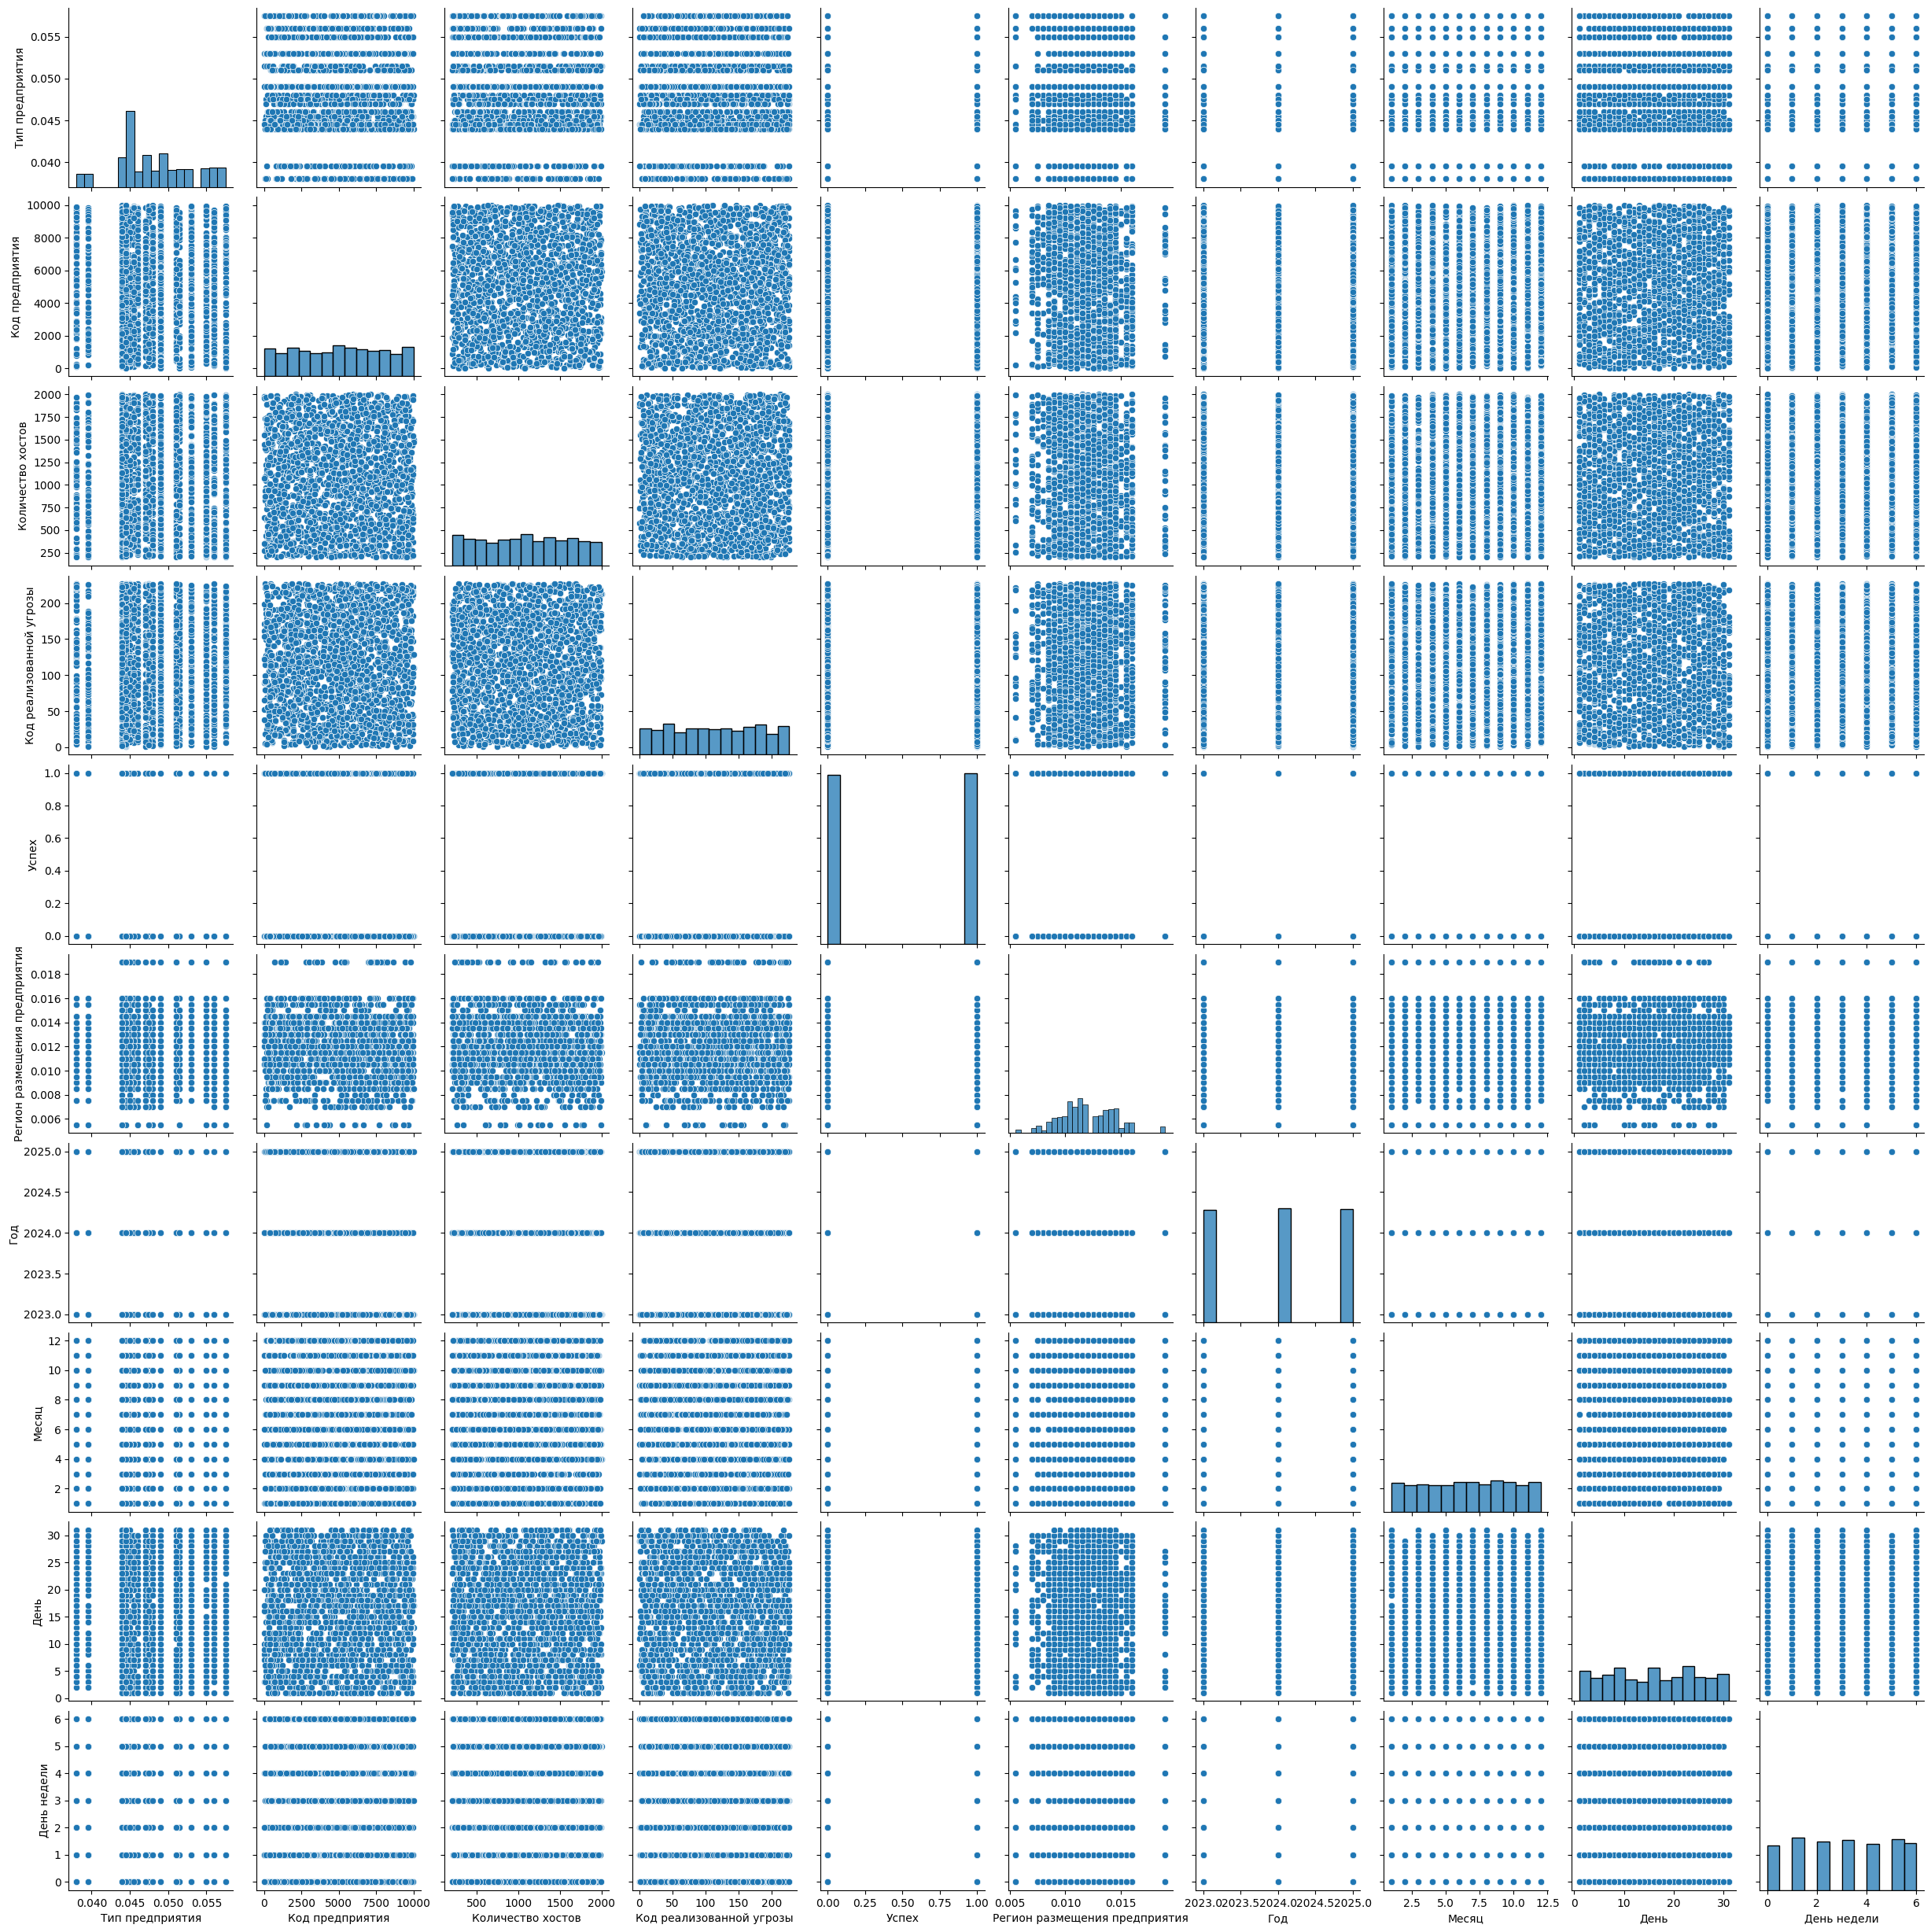

In [14]:
sns.pairplot(df_numeric)

<Axes: >

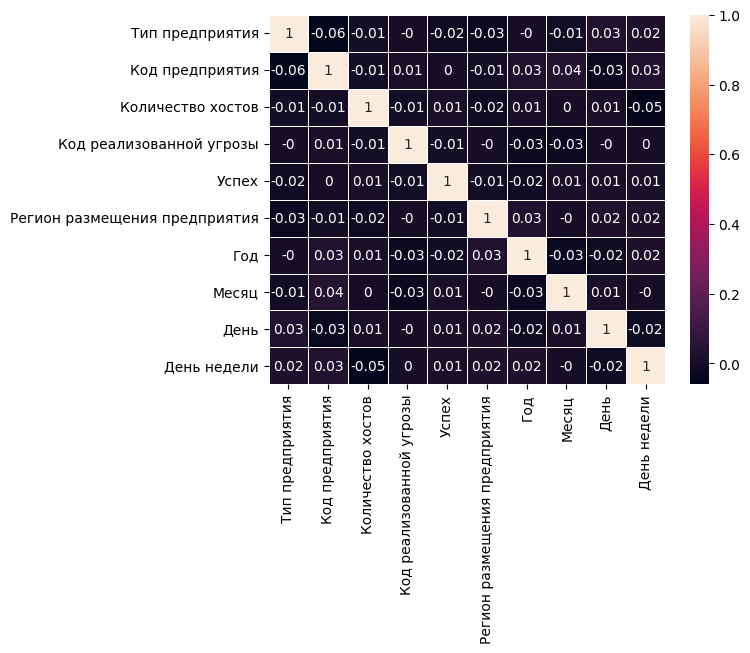

In [15]:
sns.heatmap(df_numeric.corr(numeric_only=True).round(2), annot=True, linewidths=0.5)

# Дашборд

In [16]:
def dashboard(year, region, type_enterprise):
    data = df.copy()
    if year != "all":
        data = data[data["Год"] == int(year)]
    if region != "all":
        data = data[data["Регион размещения предприятия"] == region]
    if type_enterprise != "all":
        data = data[data["Тип предприятия"] == type_enterprise]

    incidents_for_month = (
        data.groupby("Месяц")["Код реализованной угрозы"]
        .count()
        .reset_index(name="Количество инцидентов")
        .sort_values("Месяц")
    )
    fig_incidents_for_month = px.line(
        incidents_for_month,
        x="Месяц",
        y="Количество инцидентов",
        markers=True,
        title="Число инцидентов по месяцам",
    )

    incidents_for_region = (
        data.groupby("Регион размещения предприятия")["Код реализованной угрозы"]
        .count()
        .reset_index(name="Количество инцидентов")
        .sort_values("Количество инцидентов", ascending=False)
        .head(10)
    )
    fig_incidents_for_region = px.bar(
        incidents_for_region,
        x="Регион размещения предприятия",
        y="Количество инцидентов",
        title="Топ-10 регионов по числу инцидентов",
    )

    incidents_for_type = (
        data.groupby(["Тип предприятия", "Успех"])["Код реализованной угрозы"]
        .count()
        .reset_index(name="Количество инцидентов")
    )
    fig_incidents_for_type = px.bar(
        incidents_for_type,
        x="Тип предприятия",
        y="Количество инцидентов",
        color="Успех",
        title="Число инциденты по типу предприятия и успешности",
    )

    incidents_for_count = (
        data.groupby(["Тип предприятия", "Количество хостов"])["Код реализованной угрозы"]
        .count()
        .reset_index(name="Количество инцидентов")
    )
    fig_incidents_for_count = px.scatter(
        incidents_for_count,
        x="Тип предприятия",
        y="Количество инцидентов",
        color="Количество хостов",
        title="Число инциденты по типу предприятия и количеству хостов",
    )

    return fig_incidents_for_month, fig_incidents_for_region, fig_incidents_for_type, fig_incidents_for_count

years = ["all"] + sorted(df["Год"].unique().tolist())
regions = ["all"] + sorted(df["Регион размещения предприятия"].unique().tolist())
types = ["all"] + sorted(df["Тип предприятия"].unique().tolist())

demo = gr.Interface(
    fn=dashboard,
    inputs=[
        gr.Dropdown(choices=years, value="all", label="Год"),
        gr.Dropdown(choices=regions, value="all", label="Регион"),
        gr.Dropdown(choices=types, value="all", label="Тип предприятия"),
    ],
    outputs=[
        gr.Plot(),
        gr.Plot(),
        gr.Plot(),
        gr.Plot(),
    ],
    title="Дашборд по инцидентам ИБ",
    description="Фильтры по году, региону и типу предприятия.",
)

demo.launch()


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
